In [13]:
import jax
import jax.numpy as jnp
import jax.random as jr
import numpyro.distributions as dist
import matplotlib.pyplot as plt
import dynestyx as dsx
from dynestyx.inference.configs.filter import EKFConfig, EnKFConfig
from dynestyx.inference.configs.smoother import EKFSmootherConfig, EnRTSSmootherConfig

from dynestyx import DynamicalModel, GaussianStateEvolution, DiracStateEvolution
from dynestyx import DiracObservation, GaussianObservation
from dynestyx import DiracInitialCondition, GaussianInitialCondition
from dynestyx import Layout

# Structured discrete dynamics

In some cases, our dynamics are easier to define on a structured state space. We consider a toy example where our dynamics are given by two components, a latent state $z_k\in \mathbb{R}^{2}$ and an observed **matrix valued state** $x_{k} \in \mathbb{R}^{3 \times 4}$.

$$
\begin{aligned}
z_{k+1} &= \alpha z_{k} + \eta_k\\
x_{k+1} &=  x_k + (Az_{k})\mathbf{1}^\intercal + \xi_k \\
y_k &= x_k + \zeta_k 
\end{aligned}
$$

The matrix $A \in \mathbb{R}^{3\times 2}$ couples the latent space to the observed state. While it is possible to formulate these dynamics as a flat vector $y_k \in \mathbb{R}^{14}$, this can be cumbersome. Fortunately, Dynestyx allows us to easily define stuctured dynamics.

To start we will consider the case where $\eta_k, \xi_k, \zeta_k$ have diagonal covariance with identical variances given by $\sigma^2$. 

To specify dynamics on structured spaces, we must 

In [14]:
# This will be our structured state.
initial_state = {
    "latent": jnp.array([0.5, -0.5]),
    "observed": jnp.zeros((3, 4)),
}

key = jr.PRNGKey(0)
A = jr.normal(key, (3, 2))
alpha = 0.9
# Transition function
def step(state, u, t_now, t_next):
    return {
        "latent": state["latent"]*alpha,
        "observed": state["observed"] + (A @ state["latent"])[:, None]
    }
# Observation function
def observation_function(state, u, t):
    return state["observed"]

# We can infer the state and observation layouts from an example state. This allows us to use structured states in our model.
state_layout = Layout.from_example(initial_state)
observation_layout = Layout.from_example(observation_function(initial_state, None, 0.0))

In [15]:
flat_initial = state_layout.flatten(initial_state)
assert jnp.array_equal(state_layout.flatten(state_layout.unflatten(flat_initial)), flat_initial)
print("Flat state dimension:", state_layout.state_dim)
print("Leaf shapes:", jax.tree.map(lambda x: x.shape, initial_state))

Flat state dimension: 14
Leaf shapes: {'latent': (2,), 'observed': (3, 4)}


In [16]:
sigma = 0.5
# Defining the dynamics
initial_condition = GaussianInitialCondition(initial_state, state_layout=state_layout, cov = sigma**2)
evolution = GaussianStateEvolution(F=step, state_layout=state_layout, cov = sigma**2)
observation_model = GaussianObservation(observation_function, state_layout=state_layout, observation_layout=observation_layout, cov = sigma**2)
dynamics = DynamicalModel(
    initial_condition=initial_condition,
    state_evolution=evolution,
    observation_model=observation_model,
    state_layout=state_layout,
    observation_layout=observation_layout
)

In [17]:
times = jnp.arange(20.0)
result = dsx.simulate(dynamics, rng_key=jr.key(12), predict_times=times, n_simulations=2)
assert result.state_layout == state_layout
assert jnp.array_equal(state_layout.flatten(result.states), result.flatten().states)
print("Flat trajectory shape:", result.flatten().states.shape)
print("Structured trajectory shapes:", jax.tree.map(lambda x: x.shape, result.states))

Flat trajectory shape: (2, 20, 14)
Structured trajectory shapes: {'latent': (2, 20, 2), 'observed': (2, 20, 3, 4)}


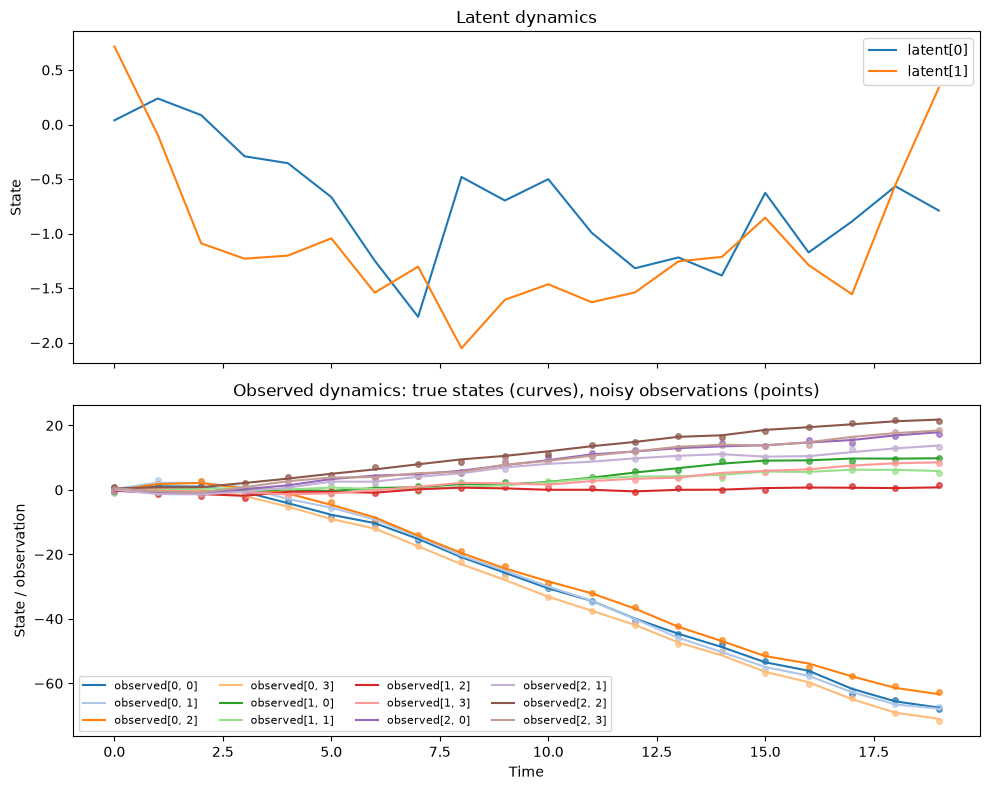

In [18]:
# Plot the first simulated trajectory.
simulation_index = 0
fig, (ax_latent, ax_observed) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

latent = result.states["latent"][simulation_index]
for i in range(latent.shape[-1]):
    ax_latent.plot(times, latent[:, i], label=f"latent[{i}]")
ax_latent.set(title="Latent dynamics", ylabel="State")
ax_latent.legend()

true_observed = result.states["observed"][simulation_index]
actual_observations = result.observations[simulation_index]
colors = plt.get_cmap("tab20")
for i in range(true_observed.shape[1]):
    for j in range(true_observed.shape[2]):
        color = colors(i * true_observed.shape[2] + j)
        ax_observed.plot(
            times, true_observed[:, i, j], color=color, label=f"observed[{i}, {j}]",
        )
        ax_observed.scatter(
            times, actual_observations[:, i, j], color=color, s=16, alpha=0.7,
        )
ax_observed.set(
    title="Observed dynamics: true states (curves), noisy observations (points)",
    xlabel="Time", ylabel="State / observation",
)
ax_observed.legend(ncol=4, fontsize=8)
fig.tight_layout()
plt.show()


## Defining the dynamics in the "flat space"

For illustration and verfication purposes, we define the exact same dynamics in the "flat" or vector space. Under the hood, Dynestyx runs exactly these dynamics. We verify that both approaches give us the same answer.

Here we define the dynamics on the flat spase. As you cann see this requires some care and can be cumbersome. 

In [19]:
# The same model on flat vectors, without Layout in the transition.
manual_flat_initial = jnp.concatenate([
    initial_state["latent"],
    initial_state["observed"].reshape(-1),
])

assert jnp.array_equal(manual_flat_initial, flat_initial)

# Defining the dynamics for flat vectors requires some care, Dynestyx can do all of this automatically!
def step_flat(x, u, t_now, t_next):
    latent = x[:2]
    observed = x[2:].reshape((3, 4))

    next_latent = latent*alpha
    next_observed = (observed + (A @ latent)[:, None]).reshape(-1)
   
    return jnp.concatenate([next_latent, next_observed])

def observation_function_flat(x, u, t_now):
    observed = x[2:]
    return observed

initial_condition_flat = GaussianInitialCondition(manual_flat_initial, cov = sigma**2)
evolution_flat = GaussianStateEvolution(F=step_flat, cov = sigma**2)
observation_model_flat = GaussianObservation(observation_function_flat, cov = sigma**2)
dynamics_flat = DynamicalModel(
    initial_condition=initial_condition_flat,
    state_evolution=evolution_flat,
    observation_model=observation_model_flat
)

result_flat = dsx.simulate(
    dynamics_flat, rng_key=jr.key(12),predict_times=times, n_simulations=2,
)

In [20]:
# Compare the structured and flat results
assert jnp.array_equal(result.flatten().states, result_flat.states)
print("All six structured/flat transition comparisons match exactly.")
assert jnp.array_equal(result.flatten().observations, result_flat.observations)
print("Full state and observation trajectories match exactly.")

# We can also reshape the flat results back into structured form and compare
print(jax.tree.map(
        lambda x, y: jnp.allclose(x, y), 
        result.states, 
        state_layout.unflatten(result_flat.states)
    ))
print(jax.tree.map(
        lambda x, y: jnp.allclose(x, y), 
        result.observations, 
        observation_layout.unflatten(result_flat.observations)
    ))
print("Maximum trajectory difference:", float(jnp.max(jnp.abs(result.flatten().states - result_flat.states))))

All six structured/flat transition comparisons match exactly.
Full state and observation trajectories match exactly.
{'latent': Array(True, dtype=bool), 'observed': Array(True, dtype=bool)}
True
Maximum trajectory difference: 0.0


## Filtering and state inference

Filter and smooth the same Gaussian model using one simulated observation trajectory.
The observations are flattened at the inference boundary; `structured_means` restores
the state dictionary. We plot the first unobserved latent coordinate.


Marginal log likelihood: -376.8188171386719
Posterior mean shapes: {'latent': (20, 2), 'observed': (20, 3, 4)}


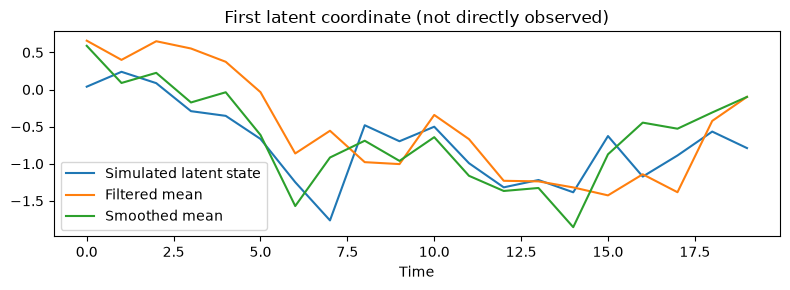

In [21]:
data = result.flatten().observations[0]
with dsx.Filter(filter_config=EnKFConfig(filter_source="cuthbert")):
    filtered = dsx.condition("system", dynamics, obs_times=times, obs_values=data)
with dsx.Smoother(smoother_config=EnRTSSmootherConfig(filter_source="cuthbert")):
    smoothed = dsx.condition("system", dynamics, obs_times=times, obs_values=data)

assert filtered.state_layout == state_layout and smoothed.state_layout == state_layout
assert jnp.isfinite(filtered.marginal_loglik)
print("Marginal log likelihood:", float(filtered.marginal_loglik))
print("Posterior mean shapes:", jax.tree.map(lambda x: x.shape, smoothed.structured_means))

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(times, result.states["latent"][0, :, 0], label="Simulated latent state")
ax.plot(times, filtered.structured_means["latent"][:, 0], label="Filtered mean")
ax.plot(times, smoothed.structured_means["latent"][:, 0], label="Smoothed mean")
ax.set(xlabel="Time", title="First latent coordinate (not directly observed)")
ax.legend()
fig.tight_layout()
plt.show()


In [22]:
# Repeat filtering and state inference with the flat dynamics and the same data.
with dsx.Filter(filter_config=EnKFConfig(filter_source="cuthbert")):
    filtered_flat = dsx.condition("system", dynamics_flat, obs_times=times, obs_values=data)
with dsx.Smoother(smoother_config=EnRTSSmootherConfig(filter_source="cuthbert")):
    smoothed_flat = dsx.condition("system", dynamics_flat, obs_times=times, obs_values=data)

for name, structured, flat in (
    ("Filtering", filtered, filtered_flat),
    ("Smoothing", smoothed, smoothed_flat),
):
    assert jnp.array_equal(structured.times, flat.times)
    assert jnp.allclose(structured.marginal_loglik, flat.marginal_loglik, rtol=1e-5, atol=1e-6)
    structured_means = state_layout.flatten(structured.structured_means)
    flat_means = jnp.stack([d.mean for d in flat.dists])
    structured_covs = jnp.stack([d.covariance_matrix for d in structured.dists])
    flat_covs = jnp.stack([d.covariance_matrix for d in flat.dists])
    assert jnp.allclose(structured_means, flat_means, rtol=1e-5, atol=1e-6)
    assert jnp.allclose(structured_covs, flat_covs, rtol=1e-5, atol=1e-6)
    print(f"{name}: likelihood, posterior means, and covariances agree.")


Filtering: likelihood, posterior means, and covariances agree.
Smoothing: likelihood, posterior means, and covariances agree.


## Parameter inference: $\alpha$

Doing parameter inference is done exactly as we usually do it.

sample: 100%|██████████| 600/600 [00:03<00:00, 151.65it/s, 1 steps of size 7.90e-01. acc. prob=0.90] 


                mean       std    median      5.0%     95.0%     n_eff     r_hat
     alpha      0.93      0.04      0.93      0.87      1.00    122.68      1.00

Number of divergences: 0


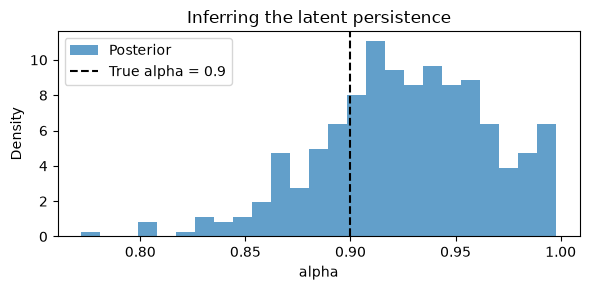

In [23]:
import numpyro
from numpyro.infer import MCMC, NUTS


def alpha_model(obs_times, obs_values):
    alpha = numpyro.sample("alpha", dist.Uniform(0.0, 1.0))

    def transition(state, u, t_now, t_next):
        return {
            "latent": alpha * state["latent"],
            "observed": state["observed"] + (A @ state["latent"])[:, None],
        }

    model = DynamicalModel(
        initial_condition=GaussianInitialCondition(initial_state, cov=sigma**2, state_layout=state_layout),
        state_evolution=GaussianStateEvolution(transition, cov=sigma**2, state_layout=state_layout),
        observation_model=GaussianObservation(
            observation_function, cov=sigma**2,
            state_layout=state_layout, observation_layout=observation_layout,
        ),
        state_layout=state_layout,
        observation_layout=observation_layout,
    )
    with dsx.Filter(filter_config=EnKFConfig(filter_source="cuthbert")):
        return dsx.sample("system", model, obs_times=obs_times, obs_values=obs_values)


mcmc = MCMC(NUTS(alpha_model), num_warmup=200, num_samples=400, num_chains=1)
mcmc.run(jr.key(42), obs_times=times, obs_values=data)
alpha_samples = mcmc.get_samples()["alpha"]
mcmc.print_summary()

fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(alpha_samples, bins=25, density=True, alpha=0.7, label="Posterior")
ax.axvline(alpha, color="black", linestyle="--", label=f"True alpha = {alpha}")
ax.set(xlabel="alpha", ylabel="Density", title="Inferring the latent persistence")
ax.legend()
fig.tight_layout()
plt.show()


## Open-loop controls

We now consider adding a two-component control term. The first control term affects the latent dynamics, whereas the second adds sensor
bias to the observations.  A `control_layout` lets both functions receive controls
as a dictionary. 

$$
\begin{aligned}
z_{k+1} &= \alpha z_{k} + u_k + \eta_k\\
x_{k+1} &=  x_k + (Az_{k})\mathbf{1}^\intercal + \xi_k \\
y_k &= x_k + \zeta_k 
\end{aligned}
$$

Here we sample controls from a Gaussian and apply them without feedback.

Pass structured control values directly to `simulate`. Controls are flattened internally
and restored before
calling the transition and observation functions.


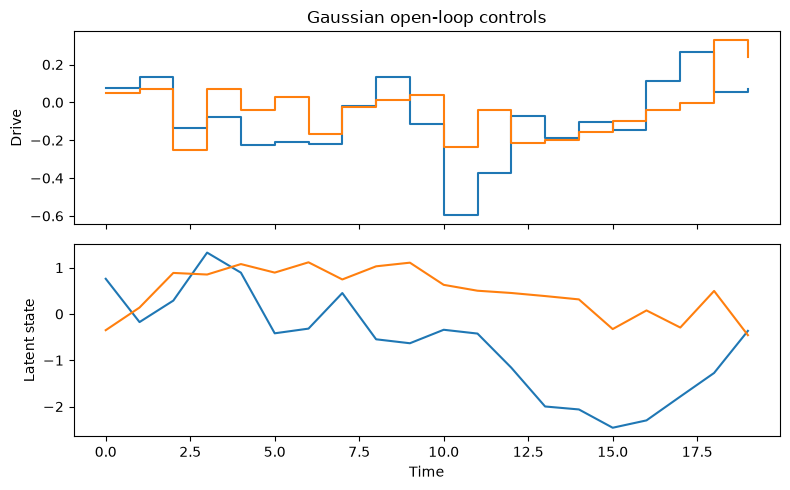

In [24]:
control_layout = Layout.from_example({
    "drive": jnp.zeros(2),
    "sensor_bias": jnp.zeros((3, 4)),
})
drive_key, bias_key = jr.split(jr.key(50))
controls = {
    "drive": 0.2 * jr.normal(drive_key, (len(times), 2)),
    "sensor_bias": 0.1 * jr.normal(bias_key, (len(times), 3, 4)),
}


def controlled_step(state, control, t_now, t_next):
    return {
        "latent": state["latent"]*alpha + control["drive"],
        "observed": state["observed"] + (A @ state["latent"])[:, None]
    }

def controlled_observation(state, control, t):
    return state["observed"] + control["sensor_bias"]


controlled_dynamics = DynamicalModel(
    initial_condition=GaussianInitialCondition(initial_state, cov=sigma**2, state_layout=state_layout),
    state_evolution=GaussianStateEvolution(controlled_step, cov=sigma**2, state_layout=state_layout),
    observation_model=GaussianObservation(
        controlled_observation, cov=sigma**2, observation_layout=observation_layout,
    ),
    state_layout=state_layout,
    observation_layout=observation_layout,
    control_layout=control_layout,
)
controlled_result = dsx.simulate(
    controlled_dynamics, rng_key=jr.key(51), predict_times=times,
    ctrl_times=times, ctrl_values=controls,
)

fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
axes[0].step(times, controls["drive"], where="post")
axes[0].set(ylabel="Drive", title="Gaussian open-loop controls")
axes[1].plot(times, controlled_result.states["latent"][0])
axes[1].set(xlabel="Time", ylabel="Latent state")
fig.tight_layout()
plt.show()


# Defining more complicated transitions using `Layout`

The helper function `GaussianStateEvolution` only supports diagonal covariances. We now illustrate how to define arbitray initial conditions, state transitions and observation functions using the `Layout` class.


In this example we let the per component noises to be independent $\eta_k \perp \xi_k \perp \zeta_k$ and with the following distributions 

$$
\begin{aligned}
&\eta_k \sim \mathcal{N}(0, Q) \\
&\zeta_k \sim \mathcal{N}(0, K) \\
&\xi_k \sim \mathcal{N}(0, R)
\end{aligned}
$$

We also define the initial condition to be given by 

$$
z_0 \sim \mathcal{N}(\mu_z, \sigma^2I) \\
x_0 \sim \mathcal{N}(\mu_x, \sigma^2I)
$$
where these are interpreted as flat vectors.

Because $x$ is matrix valued, we still have to do a bit of work to properly define its distributions in Numpyro.

In [25]:
initial_state = {
    "latent": jnp.array([0.5, -0.5]),
    "observed": jnp.zeros((3, 4)),
}

state_layout = Layout.from_example(initial_state)
flat_initial = state_layout.flatten(initial_state)


In [26]:
sigma = 0.5
def custom_initial_condition(initial_state):
    mean = state_layout.flatten(initial_state)
    cov = sigma**2 * jnp.eye(state_layout.state_dim)
    return dist.MultivariateNormal(loc=mean, covariance_matrix=cov)


In [27]:
key = jr.PRNGKey(0)
key, subkey = jr.split(key)
Q = jr.normal(subkey, (2, 2))/jnp.sqrt(2)
Q = Q @ Q.T + 0.1 * jnp.eye(2) 

key, subkey = jr.split(key)
K = jr.normal(subkey, (12,12))/jnp.sqrt(12)
K = K @ K.T + 0.1 * jnp.eye(12)  

cov = {
    "latent": Q,
    "observed": K
}

def custom_evolution(x ,u , t_now, t_next):
    x_structured = x  # DynamicalModel already supplies the structured state
    next_x_structured = step(x_structured, u, t_now, t_next)

    # This makes it easy to extract the relevant components.
    mean_latent = next_x_structured["latent"]
    mean_observed = next_x_structured["observed"].reshape(-1)

    mean = jnp.concatenate([mean_latent, mean_observed])

    cov = jnp.block([
        [Q, jnp.zeros((Q.shape[0], K.shape[1]))],
        [jnp.zeros((K.shape[0], Q.shape[1])), K]
    ])

    return dist.MultivariateNormal(loc=mean, covariance_matrix=cov)

In [28]:
key, subkey = jr.split(key)
R = jr.normal(subkey, (12,12))/jnp.sqrt(12)
R = R @ R.T + 0.1 * jnp.eye(12) 

def custom_observation(x, u, t):
    x_structured = x
    observed = observation_function(x_structured, u, t).reshape(-1)
    return dist.MultivariateNormal(loc=observed, covariance_matrix=R)

In [29]:
# Defining the dynamics
initial_condition = custom_initial_condition(initial_state)
evolution = custom_evolution
observation_model = custom_observation
dynamics = DynamicalModel(
    initial_condition=initial_condition,
    state_evolution=evolution,
    observation_model=observation_model,
    state_layout=state_layout,
    observation_layout=observation_layout
)

In [30]:
result = dsx.simulate(
    dynamics, rng_key=jr.key(12),predict_times=times, n_simulations=2,
)

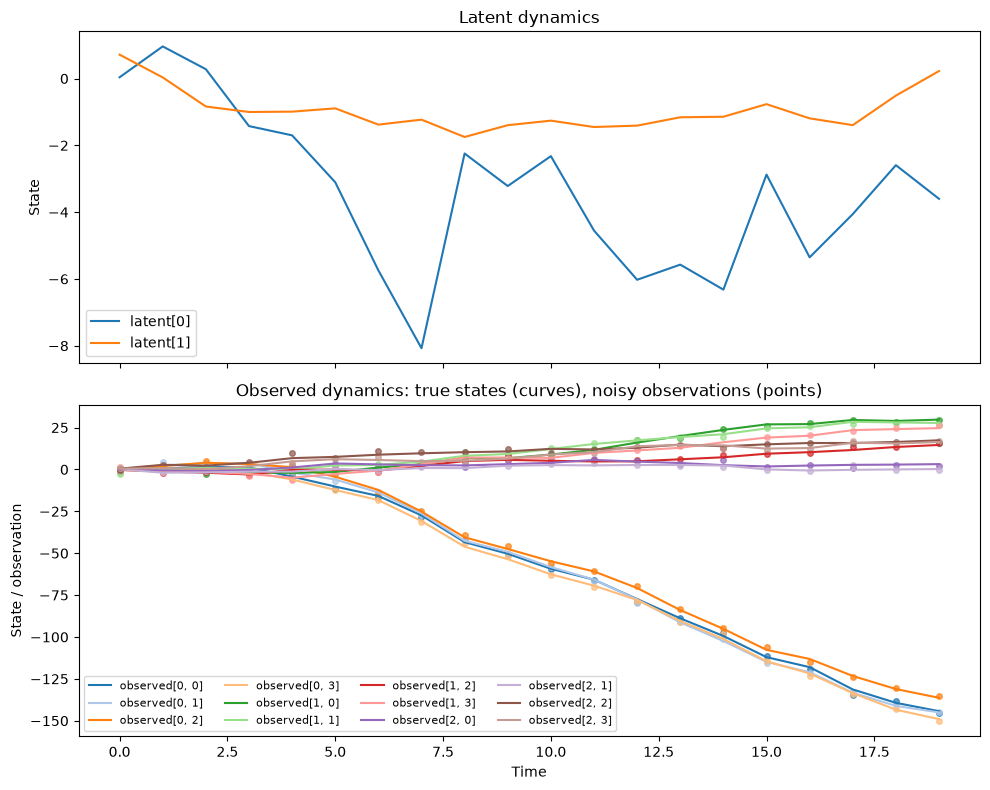

In [31]:
# Plot the first simulated trajectory.
simulation_index = 0
fig, (ax_latent, ax_observed) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

latent = result.states["latent"][simulation_index]
for i in range(latent.shape[-1]):
    ax_latent.plot(times, latent[:, i], label=f"latent[{i}]")
ax_latent.set(title="Latent dynamics", ylabel="State")
ax_latent.legend()

true_observed = result.states["observed"][simulation_index]
actual_observations = result.observations[simulation_index]
colors = plt.get_cmap("tab20")
for i in range(true_observed.shape[1]):
    for j in range(true_observed.shape[2]):
        color = colors(i * true_observed.shape[2] + j)
        ax_observed.plot(
            times, true_observed[:, i, j], color=color, label=f"observed[{i}, {j}]",
        )
        ax_observed.scatter(
            times, actual_observations[:, i, j], color=color, s=16, alpha=0.7,
        )
ax_observed.set(
    title="Observed dynamics: true states (curves), noisy observations (points)",
    xlabel="Time", ylabel="State / observation",
)
ax_observed.legend(ncol=4, fontsize=8)
fig.tight_layout()
plt.show()
